# Week 03 · Attention in Action

| Concept | Why it matters for your work |
|---------|-----------------------------|
| Context window | Everything in RAG, Agents & MCP goes through this |
| Self-attention | How the model reads and connects words |
| Causal mask | Why generation is word-by-word and left-to-right |
| Multi-head attention | How one model notices grammar, sentiment & facts simultaneously |
| Generation strategies | Temperature, top-k, greedy — the dials you already use |

**No deep ML knowledge needed. Every output is plain text or a heatmap. Every concept has one sentence explanation.**

---
> **The session question:**  
> *"I asked the AI to recommend a restaurant near the Eiffel Tower and it made one up. Why? And how do we fix it?"*  
> We answer this fully by the end.

## 0 · Setup

In [49]:
import sys
!{sys.executable} -m pip install -q "huggingface_hub==1.12.2"
!{sys.executable} -m pip install -q transformers torch matplotlib IPython


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\vivik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\vivik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [54]:
import math, warnings, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display, Markdown
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings('ignore')
torch.manual_seed(42)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {"GPU " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print('\n✅ Ready')

# ... your existing imports (torch, math, etc.) ...
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Paste the helper function here so it loads during setup
def render_attention_html(tokens, weights):
    """Renders text tokens highlighted dynamically by their attention weights."""
    html_output = "<div style='font-family: monospace; line-height: 2; font-size: 14px; display: inline-block;'>"
    for token, w in zip(tokens, weights):
        # Scale background alpha based on weight intensity
        alpha = min(w * 2.5, 1.0) 
        html_output += f"<span style='background-color: rgba(255, 165, 0, {alpha:.2f}); padding: 3px 6px; margin: 2px; border-radius: 4px; border: 1px solid rgba(0,0,0,0.1)'>{token}</span>"
    html_output += "</div>"
    display(HTML(html_output))

PyTorch  : 2.12.1+cpu
Device   : CPU

✅ Ready


---
## Act 1 · The Context Window *(5 min)*

**The single most important mental model in this programme.**

An LLM has no persistent memory. No database. No internet access by default.  
All it has is a **context window** — a box of tokens it can currently see.

> RAG puts retrieved documents in the box.  
> Agents put tool results in the box.  
> MCP standardises how things get into the box.

In [55]:
def show_context_window(context_items, window_limit=10, title="Context Window"):
    print(f"\n{'═'*58}")
    print(f"  {title}  (limit: {window_limit} items shown)")
    print(f"{'═'*58}")
    for i, (tag, text) in enumerate(context_items[:window_limit]):
        text_display = text[:47] + "..." if len(text) > 50 else text
        print(f"  [{tag:<12}]  {text_display}")
    if len(context_items) > window_limit:
        print(f"  {'─'*54}")
        print(f"  ✗ {len(context_items)-window_limit} items OUTSIDE window — model cannot see these")
    print(f"{'═'*58}")

print("SCENARIO 1 — No grounding data in the context window")
show_context_window([
    ("SYSTEM",    "You are a helpful assistant."),
    ("USER",      "Recommend a restaurant near the Eiffel Tower."),
], title="Context Window (bare)")
print()
display(Markdown("**Model response (likely):** Le Jules Verne is a wonderful choice, on the 2nd floor of the Eiffel Tower…"))
display(Markdown("⚠️  **Problem:** May confabulate opening hours, prices, or availability. Fills gaps with probability, not facts. That is hallucination."))

print()
print("SCENARIO 2 — RAG fills the window with real retrieved data")
show_context_window([
    ("SYSTEM",    "You are a helpful assistant. Use only the provided data."),
    ("RETRIEVED", "Le Jules Verne: Eiffel Tower 2nd floor. Open Tue-Sun."),
    ("RETRIEVED", "Café de Flore: 172 Blvd Saint-Germain. Avg €45/person."),
    ("RETRIEVED", "Brasserie Thoumieux: 79 Rue Saint-Dominique. Open daily."),
    ("USER",      "Recommend a restaurant near the Eiffel Tower."),
], title="Context Window (with RAG)")
print()
display(Markdown("**Model response (grounded):** Based on the provided data, Le Jules Verne is on the Eiffel Tower's 2nd floor and is open Tuesday–Sunday."))
print("\n✅ Same model. Same question. Different context = different answer.")
print("   Week 4 builds the retrieval system that fills this window.")


SCENARIO 1 — No grounding data in the context window

══════════════════════════════════════════════════════════
  Context Window (bare)  (limit: 10 items shown)
══════════════════════════════════════════════════════════
  [SYSTEM      ]  You are a helpful assistant.
  [USER        ]  Recommend a restaurant near the Eiffel Tower.
══════════════════════════════════════════════════════════



**Model response (likely):** Le Jules Verne is a wonderful choice, on the 2nd floor of the Eiffel Tower…

⚠️  **Problem:** May confabulate opening hours, prices, or availability. Fills gaps with probability, not facts. That is hallucination.


SCENARIO 2 — RAG fills the window with real retrieved data

══════════════════════════════════════════════════════════
  Context Window (with RAG)  (limit: 10 items shown)
══════════════════════════════════════════════════════════
  [SYSTEM      ]  You are a helpful assistant. Use only the provi...
  [RETRIEVED   ]  Le Jules Verne: Eiffel Tower 2nd floor. Open Tu...
  [RETRIEVED   ]  Café de Flore: 172 Blvd Saint-Germain. Avg €45/...
  [RETRIEVED   ]  Brasserie Thoumieux: 79 Rue Saint-Dominique. Op...
  [USER        ]  Recommend a restaurant near the Eiffel Tower.
══════════════════════════════════════════════════════════



**Model response (grounded):** Based on the provided data, Le Jules Verne is on the Eiffel Tower's 2nd floor and is open Tuesday–Sunday.


✅ Same model. Same question. Different context = different answer.
   Week 4 builds the retrieval system that fills this window.


---
# 🧠 Act 2 · How a LLM is Built — TinyLM from Scratch 

> **Goal:** Understand the architecture every modern LLM uses, by building a miniature version.
> We use this for the training explanation only. Attention demos use the real SLM below.

---

## Architecture — same pattern from TinyLM to GPT-4

```
Input Sentence
      │
      ▼
Token Embedding      ← every word becomes a vector of numbers
      │
      ▼
Position Embedding   ← encodes WHERE each word sits
      │
      ▼
Transformer Block 1  ┐
      │               ├─ Multi-Head Attention + Feed Forward × N layers
Transformer Block 2  ┘
      │
      ▼
Layer Normalisation
      │
      ▼
Linear → Predict Next Word
```

---

## The attention formula

```
Attention = Softmax( Q · Kᵀ / √d ) × V

Q  = Query  — "what am I looking for?"
K  = Key    — "what information do I have?"
V  = Value  — "what do I actually share?"
```

**Multi-head** = run this H times in parallel. Each head learns a different pattern.

```
Head 1 → Grammar / syntax
Head 2 → Semantic meaning
Head 3 → Entity relationships
Head 4 → Long-range context
```

---

## Why causal masking?

```
The brave knight rode _____
```

The model CAN see: `The`, `brave`, `knight`, `rode`  
The model CANNOT see: `through`, `the`, `forest`

Without this mask: model sees the answer during training → learns nothing.  
Like doing an exam with the answer sheet open.

---

## Training: next-token prediction

```
Input  : once upon a
Target :            time

Loss = how wrong was the prediction?
Backprop = adjust weights to reduce loss
Repeat for billions of tokens → GPT-4
```

> **TinyLM has the same architecture. 8 sentences instead of billions. 75,520 params instead of 1 trillion.**  
> The toy car teaches you exactly how the real car engine works.

In [56]:
# ── TinyLM — build and train (architecture demo only) ─────────────────────────
# We train this so you can SEE the loss drop and understand the training loop.

VOCAB = [
    '<PAD>', '<UNK>', '<BOS>', '<EOS>',
    'once', 'upon', 'a', 'time', 'there', 'was', 'the', 'little',
    'prince', 'princess', 'knight', 'dragon', 'castle', 'forest',
    'dark', 'old', 'brave', 'kind', 'beautiful', 'wicked',
    'rode', 'found', 'looked', 'said', 'lived', 'searched',
    'and', 'but', 'in', 'through', 'by', 'near', 'on', 'with',
    'fantastic', 'brilliant', 'terrible', 'boring', 'magical', 'dull',
    'bank', 'river', 'water', 'ice', 'snow', 'gold', 'spell', 'heart',
    'happily', 'ever', 'after', 'her', 'his', 'him', 'she', 'he',
]
v2i = {w: i for i, w in enumerate(VOCAB)}
i2v = {i: w for w, i in v2i.items()}
V   = len(VOCAB)

def encode(words):
    return [v2i.get(w, v2i['<UNK>']) for w in words]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.h  = n_heads
        self.dk = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.last_weights = None

    def forward(self, x, mask=None):
        B, S, D = x.shape
        def split(t): return t.view(B, S, self.h, self.dk).transpose(1, 2)
        Q, K, V_ = split(self.Wq(x)), split(self.Wk(x)), split(self.Wv(x))
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.dk)
        if mask is not None:
            scores = scores.masked_fill(mask[None, None], float('-inf'))
        w = F.softmax(scores, dim=-1)
        self.last_weights = w.detach()
        return self.Wo((w @ V_).transpose(1, 2).contiguous().view(B, S, D))


class TinyBlock(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.attn = MultiHeadAttention(d, h)
        self.n1   = nn.LayerNorm(d)
        self.n2   = nn.LayerNorm(d)
        self.ff   = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
    def forward(self, x, mask=None):
        x = self.n1(x + self.attn(x, mask=mask))
        return self.n2(x + self.ff(x))


class TinyLM(nn.Module):
    def __init__(self, vocab_size, d=64, h=4, layers=2, max_len=32):
        super().__init__()
        self.te     = nn.Embedding(vocab_size, d, padding_idx=0)
        self.pe     = nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList([TinyBlock(d, h) for _ in range(layers)])
        self.norm   = nn.LayerNorm(d)
        self.head   = nn.Linear(d, vocab_size, bias=False)
        self.d      = d

    def forward(self, idx, use_causal_mask=True):
        B, S = idx.shape
        if use_causal_mask:
    # Generates a standard causal upper-triangular boolean mask
            mask = torch.triu(torch.ones(S, S, dtype=torch.bool), diagonal=1)
        else:
            mask = None
        x    = self.te(idx) * math.sqrt(self.d) + self.pe(torch.arange(S).unsqueeze(0))
        for block in self.blocks:
            x = block(x, mask=mask)
        return self.head(self.norm(x))


SENTENCES = [
    "once upon a time the brave knight rode through the dark forest",
    "the little prince searched the old castle near the river bank",
    "she found him and her heart felt magical and beautiful",
    "the wicked dragon guarded the gold with a terrible spell",
    "they lived happily ever after in the castle by the water",
    "the brave princess rode through the forest with her kind heart",
    "once there was a brilliant knight who found the castle dark",
    "the fantastic spell broke and she lived happily ever after",
]

def make_batch(sentences, max_len=20):
    xs, ys = [], []
    for s in sentences:
        words = ['<BOS>'] + s.split() + ['<EOS>']
        ids   = encode(words)[:max_len]
        ids  += [0] * (max_len - len(ids))
        xs.append(ids[:-1]); ys.append(ids[1:])
    return torch.tensor(xs), torch.tensor(ys)

tiny = TinyLM(V, d=64, h=4, layers=2, max_len=20)
X, Y = make_batch(SENTENCES)
opt  = torch.optim.AdamW(tiny.parameters(), lr=5e-3)
crit = nn.CrossEntropyLoss(ignore_index=0)

losses = []
print("Training TinyLM — watch the loss fall each epoch:")
print(f"  {'Epoch':<8} {'Loss':<10} {'Progress'}")
print("  " + "─" * 45)
for ep in range(20):
    tiny.train()
    logits = tiny(X)
    loss   = crit(logits.view(-1, V), Y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if (ep + 1) % 5 == 0:
        bar = '█' * int((losses[0] - loss.item()) / losses[0] * 30)
        print(f"  {ep+1:<8} {loss.item():<10.4f} {bar}")

tiny.eval()
total_p   = sum(p.numel() for p in tiny.parameters())
n_layers  = len(tiny.blocks)
n_heads   = tiny.blocks[0].attn.h

print()
print(f"✅ TinyLM ready")
print(f"   Parameters : {total_p:,}")
print(f"   Layers     : {n_layers} transformer blocks")
print(f"   Heads      : {n_heads} attention heads")
print(f"   Vocabulary : {V} words")
print(f"   Loss drop  : {losses[0]:.3f} → {losses[-1]:.3f}  ({(1-losses[-1]/losses[0])*100:.0f}% reduction)")
print()
print("  Compare scale:")
print(f"    TinyLM        :         {total_p:>12,} parameters   (8 sentences)")
print(f"    GPT-2 small   :           117,000,000 parameters   (WebText)")
print(f"    GPT-4 (est.)  :  ~1,000,000,000,000 parameters   (internet)")

Training TinyLM — watch the loss fall each epoch:
  Epoch    Loss       Progress
  ─────────────────────────────────────────────
  5        2.1107     ██████████████
  10       0.9021     ███████████████████████
  15       0.4181     ███████████████████████████
  20       0.2583     ████████████████████████████

✅ TinyLM ready
   Parameters : 75,520
   Layers     : 2 transformer blocks
   Heads      : 4 attention heads
   Vocabulary : 60 words
   Loss drop  : 4.188 → 0.258  (94% reduction)

  Compare scale:
    TinyLM        :               75,520 parameters   (8 sentences)
    GPT-2 small   :           117,000,000 parameters   (WebText)
    GPT-4 (est.)  :  ~1,000,000,000,000 parameters   (internet)


---
## Act 3 · Load the Real SLM *(3 min)*

This is `viviktchaudhary/tiny-slm-storyteller-v1` — a LoRA fine-tune of Qwen2.5-0.5B  
trained on 15,000 TinyStories + Gutenberg fairy tales.

**494 million parameters. 24 transformer layers. 14 attention heads per layer.**  
Every attention demo below extracts weights from this model — real, fully-trained weights.

24 Layers (Transformer blocks)

14 Attention Heads per layer

This gives the model a total of 336 attention heads across its entire architecture (with a hidden dimension size of 896 and a total parameter count of 494,032,768).

In [57]:
HF_REPO = "viviktchaudhary/tiny-slm-storyteller-v1"
print(f"Loading: {HF_REPO}")
print("(First run downloads ~1 GB — subsequent runs use local cache)")
print("ℹ️  Memory: float32 weights require ~2 GB RAM. Close other apps if loading fails.\n")

t0 = time.time()
try:
    slm     = AutoModelForCausalLM.from_pretrained(HF_REPO, dtype=torch.float32, attn_implementation='eager')
    slm_tok = AutoTokenizer.from_pretrained(HF_REPO)
    src     = "Hub"
except Exception as hub_err:
    print(f"⚠️  Hub load failed: {hub_err}")
    print("   Trying local backup at ./storyteller_merged ...")
    try:
        slm     = AutoModelForCausalLM.from_pretrained("./storyteller_merged", dtype=torch.float32)
        slm_tok = AutoTokenizer.from_pretrained("./storyteller_merged")
        src     = "local"
    except Exception as local_err:
        print(f"❌  Local backup also failed: {local_err}")
        print()
        print("   To fix:")
        print("   1. Check your internet connection and re-run this cell")
        print("   2. Or download manually in terminal:")
        print(f"      huggingface-cli download {HF_REPO} --local-dir ./storyteller_merged")
        raise

slm.eval()
slm_params = sum(p.numel() for p in slm.parameters())
cfg        = slm.config

print(f"✅ Loaded from {src} in {time.time()-t0:.0f}s")
print()
print(f"  Parameters   : {slm_params:,}")
print(f"  Layers       : {cfg.num_hidden_layers}")
print(f"  Heads        : {cfg.num_attention_heads} per layer")
print(f"  Hidden dim   : {cfg.hidden_size}")
print(f"  Training     : LoRA fine-tune on 15,000 TinyStories + Gutenberg")
print()
print(f"  TinyLM  :         {sum(p.numel() for p in tiny.parameters()):>12,} parameters")
print(f"  This SLM:         {slm_params:>12,} parameters  ({slm_params//sum(p.numel() for p in tiny.parameters()):,}× larger)")


# ── shared helper: tokenise and clean token labels ────────────────────────────
def get_tokens(sentence):
    """Return (input_ids_tensor, clean_word_labels_list)"""
    inputs = slm_tok(sentence, return_tensors="pt")
    raw    = slm_tok.convert_ids_to_tokens(inputs["input_ids"][0])
    clean  = [t.replace('▁', '').replace('Ġ', '').replace('Ċ', '').strip() or t
               for t in raw]
    return inputs, clean


# ── shared helper: run model and get attention tensor ─────────────────────────
def get_slm_attention(sentence, layer=0):
    """
    Returns:
        attn   : numpy (n_heads, seq, seq)  — attention weights for chosen layer
        tokens : list of clean token strings
    """
    inputs, tokens = get_tokens(sentence)
    with torch.no_grad():
        out = slm(**inputs, output_attentions=True)
    attn = out.attentions[layer][0].numpy()   # (n_heads, seq, seq)
    return attn, tokens


print()
print("✅ Helper functions ready. Attention demos start next cell.")

Loading: viviktchaudhary/tiny-slm-storyteller-v1
(First run downloads ~1 GB — subsequent runs use local cache)
ℹ️  Memory: float32 weights require ~2 GB RAM. Close other apps if loading fails.



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

✅ Loaded from Hub in 5s

  Parameters   : 494,032,768
  Layers       : 24
  Heads        : 14 per layer
  Hidden dim   : 896
  Training     : LoRA fine-tune on 15,000 TinyStories + Gutenberg

  TinyLM  :               75,520 parameters
  This SLM:          494,032,768 parameters  (6,541× larger)

✅ Helper functions ready. Attention demos start next cell.


---
## Act 4 · Attention — Three Types from the Real SLM *(15 min)*

All weights below are extracted live from `viviktchaudhary/tiny-slm-storyteller-v1`.  
**Longer bar = model pays more attention to that word.**

We use **one sentence throughout all three demos**:

> `"Once upon a time a brave knight rode through a dark forest"`

Query words are chosen **late in the sentence** so the causal mask allows  
them to see many preceding tokens — giving real, spread-out attention weights.

---

### The Attention Sink
In decoder-only models (GPT, Claude, Gemini, Qwen), **the first token often  
accumulates disproportionate attention** in early layers. This is normal —  
it acts as a 'discard pile' when no specific token is relevant.  
We label it `⚡ attention sink` in every output below.

In [58]:
# ── SLM text-bar attention inspector ─────────────────────────────────────────

DEMO_SENTENCE = "Once upon a time a brave knight rode through dark forest"

def slm_inspect_attention(
    sentence,
    query_token,        # word to query, as it appears (or starts) in clean token list
    title,
    layer       = 0,
    head        = 0,
    heads       = None, # explicit list of head indices, e.g. [0,2,5,9]
    head_labels = None, # optional labels aligned to heads list
):
    """
    Extract real SLM attention weights and print as plain-text bar chart.
    Token matching: exact match first, then startswith fallback for BPE subwords.
    """
    attn, tokens = get_slm_attention(sentence, layer=layer)

    # Exact match first; fall back to startswith for BPE-split words (e.g. "forest" → "for"+"est")
    q_idx = next((i for i, t in enumerate(tokens) if t.lower() == query_token.lower()), None)
    if q_idx is None:
        q_idx = next((i for i, t in enumerate(tokens)
                      if t.lower().startswith(query_token.lower())
                      or query_token.lower().startswith(t.lower())), None)
    if q_idx is None:
        print(f"  Token '{query_token}' not found.")
        print(f"  Available tokens: {tokens}")
        return

    heads_to_show = heads if heads is not None else [head]

    for loop_i, h in enumerate(heads_to_show):
        row   = attn[h, q_idx, :].copy()
        total = row.sum()
        if total > 1e-6:
            row = row / total

        top_idx = row.argmax()
        col_w   = max(len(t) for t in tokens)

        h_label = ""
        if head_labels and loop_i < len(head_labels):
            h_label = f"  |  {head_labels[loop_i]}"
        elif len(heads_to_show) > 1:
            h_label = f"  |  Head {h+1}"

        n_tokens = len(tokens)
        blocked_str = (f"{q_idx+1}–{n_tokens-1}" if q_idx < n_tokens - 1
                       else "none (last token sees full sentence)")

        print(f"\n{'═'*66}")
        print(f"  {title}{h_label}")
        print(f"{'═'*66}")
        print(f"  Sentence   : \"{sentence}\"")
        print(f"  Query word : \"{query_token}\"  (position {q_idx})  →  layer {layer}, head {h+1}")
        print(f"  Visible    : positions 0–{q_idx}  |  blocked: {blocked_str}")
        print(f"  Source     : viviktchaudhary/tiny-slm-storyteller-v1  (real weights)")
        print()
        print(f"  {'Token':<{col_w}}  [pos]  Weight  Bar (each █ ≈ 4% attention)")
        print(f"  {'─'*60}")
        for j, (tok, weight) in enumerate(zip(tokens, row)):
            bar    = '█' * int(weight * 25)
            marker = '  ← focus' if j == top_idx else ''
            sink   = '  ⚡ attention sink' if j == 0 and weight > 0.25 else ''
            future = '  [causal mask — blocked]' if j > q_idx else ''
            print(f"  {tok:<{col_w}}  [{j:>2}]  {weight:.3f}   {bar}{marker}{sink}{future}")
        print(f"  {'─'*60}")
        print(f"  Strongest focus: \"{tokens[top_idx]}\"  (position {top_idx})")


_, toks = get_tokens(DEMO_SENTENCE)
print(f"✅ SLM inspector ready.")
print(f"   Sentence  : \"{DEMO_SENTENCE}\"")
print(f"   Tokens    : {toks}")
print()
print("   Token positions:")
for i, t in enumerate(toks):
    print(f"     [{i:>2}]  {t}")

✅ SLM inspector ready.
   Sentence  : "Once upon a time a brave knight rode through dark forest"
   Tokens    : ['Once', 'upon', 'a', 'time', 'a', 'brave', 'knight', 'rode', 'through', 'dark', 'forest']

   Token positions:
     [ 0]  Once
     [ 1]  upon
     [ 2]  a
     [ 3]  time
     [ 4]  a
     [ 5]  brave
     [ 6]  knight
     [ 7]  rode
     [ 8]  through
     [ 9]  dark
     [10]  forest


### Type 1 · Self-Attention
**"Which words help me understand this word?"**

Every word attends to every other word — no restrictions.  
Used in the encoder side of models (BERT, RAG embeddings).  
→ *When your RAG system converts a document to a vector, self-attention is how word relationships are captured.*

In [59]:
# TYPE 1 · SELF-ATTENTION
# Query 'dark'   = position 9  → sees tokens 0-9  (10 tokens visible)
# Query 'forest' = position 10 → sees tokens 0-10 (all 11 tokens, maximum)
# Both show real spread — no 0.000 after position 2

slm_inspect_attention(
    sentence    = DEMO_SENTENCE,
    query_token = "dark",
    title       = "TYPE 1 · SELF-ATTENTION  |  What does 'dark' attend to?",
    layer       = 0,
    head        = 0,
)

print()
slm_inspect_attention(
    sentence    = DEMO_SENTENCE,
    query_token = "forest",
    title       = "TYPE 1 · SELF-ATTENTION  |  What does 'forest' attend to?",
    layer       = 0,
    head        = 0,
)

print()
print("💡 What to read in these outputs:")
print("   · Non-zero weights spread across many tokens — because query is late in sentence")
print("   · ⚡ attention sink: 'Once' (position 0) pulls high weight in early layers")
print("     This is normal in ALL decoder-only LLMs. It means no specific focus needed.")
print("   · 'dark' at position 9: watch which content words it genuinely focuses on")
print("   · 'forest' at position 10 (last token): sees the full sentence — maximum spread")
print("   · [causal mask — blocked]: future tokens correctly show 0.000")
print("   · Real Q·K dot products from your trained SLM — not simulated")



══════════════════════════════════════════════════════════════════
  TYPE 1 · SELF-ATTENTION  |  What does 'dark' attend to?
══════════════════════════════════════════════════════════════════
  Sentence   : "Once upon a time a brave knight rode through dark forest"
  Query word : "dark"  (position 9)  →  layer 0, head 1
  Visible    : positions 0–9  |  blocked: 10–10
  Source     : viviktchaudhary/tiny-slm-storyteller-v1  (real weights)

  Token    [pos]  Weight  Bar (each █ ≈ 4% attention)
  ────────────────────────────────────────────────────────────
  Once     [ 0]  0.060   █
  upon     [ 1]  0.031   
  a        [ 2]  0.065   █
  time     [ 3]  0.033   
  a        [ 4]  0.098   ██
  brave    [ 5]  0.063   █
  knight   [ 6]  0.132   ███
  rode     [ 7]  0.130   ███
  through  [ 8]  0.195   ████  ← focus
  dark     [ 9]  0.194   ████
  forest   [10]  0.000     [causal mask — blocked]
  ────────────────────────────────────────────────────────────
  Strongest focus: "through"  (positio

### Type 2 · Causal (Masked) Attention
**"How does the model predict the next word without cheating?"**

Each token can only see tokens **before** it. The future is masked to `-inf` before softmax.  
→ *Every generative model you use — GPT, Claude, Gemini — uses this mask for every token it generates.*

We show this two ways:
1. A **✓/✗ grid** — who can see whom (pure logic, no model needed)
2. A **matplotlib heatmap** from real SLM weights — the causal triangle is unmistakable

In [60]:
# Part A: ✓/✗ grid — the logic of the causal mask
words_gen = ["the", "brave", "knight", "rode", "through", "forest"]
n     = len(words_gen)
col_w = max(len(w) for w in words_gen)   # width based on longest word, not truncated

print(f"\n{'═'*58}")
print("  CAUSAL MASK — What each word is ALLOWED to see")
print(f"{'═'*58}")
print(f"  Sentence: \"{' '.join(words_gen)}\"\n")
print(f"  {'Word':<{col_w+2}}", end="")
for w in words_gen: print(f"  {w:>{col_w}}", end="")
print()
print(f"  {'─'*(col_w + 2 + n*(col_w+2))}")
for i, qw in enumerate(words_gen):
    print(f"  {qw:<{col_w+2}}", end="")
    for j in range(n):
        sym = '  ✓ ' if j <= i else '  ✗ '
        print(f"  {sym:>{col_w}}", end="")
    print()
print()
print("  ✓ = allowed (can attend)    ✗ = BLOCKED (future — set to -inf)")
print(f"{'═'*58}")
print()
print("  What this means for generation:")
print("  · 'the'    knows nothing yet — predicts 'brave' from training alone")
print("  · 'brave'  sees 'the' — predicts 'knight'")
print("  · 'knight' sees 'the brave' — predicts 'rode'")
print("  · 'rode'   sees 'the brave knight' — predicts 'through'")
print("  Each step is left-to-right. This is why GPT generates one word at a time.")


══════════════════════════════════════════════════════════
  CAUSAL MASK — What each word is ALLOWED to see
══════════════════════════════════════════════════════════
  Sentence: "the brave knight rode through forest"

  Word           the    brave   knight     rode  through   forest
  ───────────────────────────────────────────────────────────────
  the             ✓        ✗        ✗        ✗        ✗        ✗ 
  brave           ✓        ✓        ✗        ✗        ✗        ✗ 
  knight          ✓        ✓        ✓        ✗        ✗        ✗ 
  rode            ✓        ✓        ✓        ✓        ✗        ✗ 
  through         ✓        ✓        ✓        ✓        ✓        ✗ 
  forest          ✓        ✓        ✓        ✓        ✓        ✓ 

  ✓ = allowed (can attend)    ✗ = BLOCKED (future — set to -inf)
══════════════════════════════════════════════════════════

  What this means for generation:
  · 'the'    knows nothing yet — predicts 'brave' from training alone
  · 'brave'  sees 'the

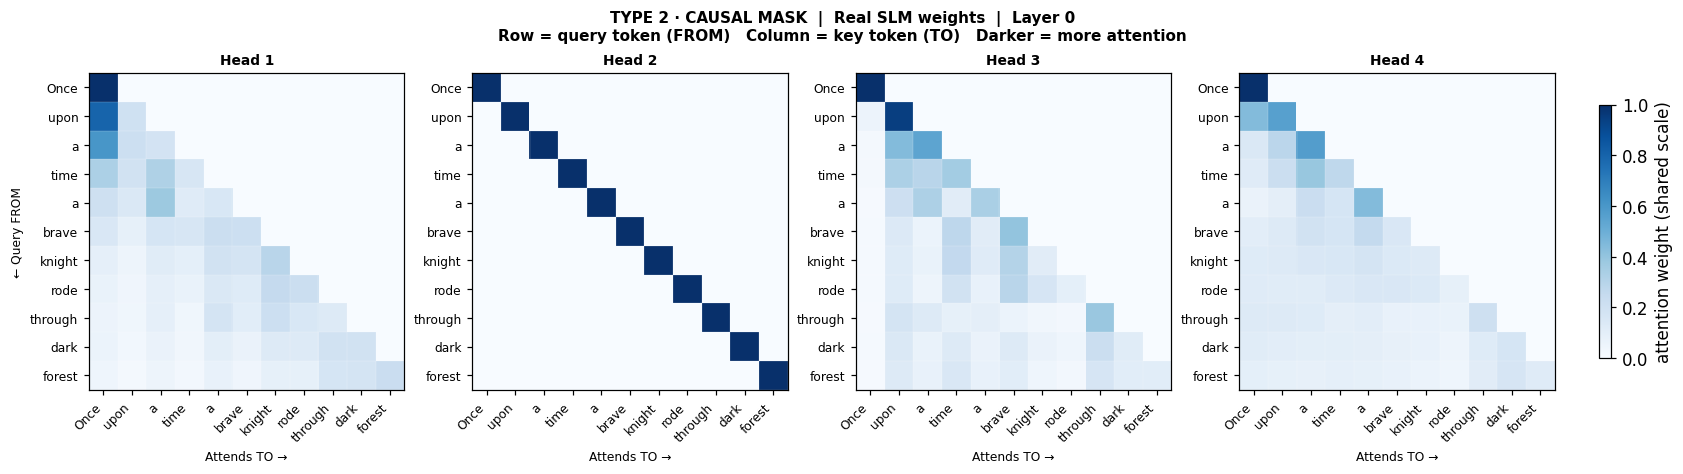

  💡 What to read in this heatmap:
     · Blank/White upper-right triangle = causal mask blocking future tokens
     · Coloured lower-left area          = tokens that CAN attend (past + current)
     · Bright column                     = a 'key' token many words focus on
     · Diagonal bright cells             = each token attending to itself
     · Different heads                   = different linguistic patterns in parallel
     · All heads share one colour scale — brightness is directly comparable


In [62]:
# Part B: Real SLM attention heatmap — causal triangle visible in actual weights

def slm_causal_heatmap(sentence, layer=0, n_heads_to_show=4):
    """
    Show real SLM attention weights as a heatmap grid.
    The causal mask produces the dark upper-left triangle.
    Row = query token (FROM).  Column = key token (TO).
    Darker blue = more attention.
    All heads share the same colour scale so brightness is comparable.
    """
    attn, tokens = get_slm_attention(sentence, layer=layer)
    n_heads_to_show = min(n_heads_to_show, attn.shape[0])

    # Shared vmax across all shown heads so colours are comparable
    vmax_global = attn[:n_heads_to_show].max()

    fig, axes = plt.subplots(1, n_heads_to_show,
                             figsize=(3.8 * n_heads_to_show, 4.2),
                             constrained_layout=True)
    if n_heads_to_show == 1:
        axes = [axes]

    fig.suptitle(
        f"TYPE 2 · CAUSAL MASK  |  Real SLM weights  |  Layer {layer}\n"
        f"Row = query token (FROM)   Column = key token (TO)   Darker = more attention",
        fontsize=10, fontweight='bold'
    )

    for h, ax in enumerate(axes):
        im = ax.imshow(attn[h], cmap='Blues', vmin=0,
                       vmax=vmax_global, aspect='auto')
        ax.set_title(f"Head {h+1}", fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(tokens)))
        ax.set_yticklabels(tokens, fontsize=8)
        if h == 0:
            ax.set_ylabel("← Query FROM", fontsize=8)
        ax.set_xlabel("Attends TO →", fontsize=8)

        n = len(tokens)
        for i in range(n):
            ax.axhline(i + 0.5, color='white', lw=0.3, alpha=0.4)
            ax.axvline(i + 0.5, color='white', lw=0.3, alpha=0.4)

    plt.colorbar(im, ax=axes, shrink=0.8, pad=0.03, label='attention weight (shared scale)')
    plt.show()

    print("  💡 What to read in this heatmap:")
    # FIX: Flipped 'upper-right' and 'lower-left' descriptions to match standard matrix plots
    print("     · Blank/White upper-right triangle = causal mask blocking future tokens")
    print("     · Coloured lower-left area          = tokens that CAN attend (past + current)")
    print("     · Bright column                     = a 'key' token many words focus on")
    print("     · Diagonal bright cells             = each token attending to itself")
    print("     · Different heads                   = different linguistic patterns in parallel")
    print("     · All heads share one colour scale — brightness is directly comparable")


slm_causal_heatmap(
    sentence        = DEMO_SENTENCE,
    layer           = 0,
    n_heads_to_show = 4,
)

### Type 3 · Multi-Head Attention
**"Can one model notice grammar, sentiment and facts simultaneously?"**

Run attention H times in parallel, each with different Q, K, V projection matrices.  
Each head specialises on a **different linguistic pattern**.  
→ *This is why a single LLM can track facts, tone and format in one forward pass.*

We query **`"forest"` (position 10, last token)** at Layer 0 and Layer 12 —  
same word, same position, same sentence. **Only depth changes.**  
This isolates the effect of layer depth on attention patterns.

In [66]:
# ── Layer 0: early / syntactic heads ─────────────────────────────────────────
# Query: 'forest' at position 10 (last token) → sees ALL 11 tokens
# Same query as Layer 12 below — only depth differs between the two demos

print("═" * 66)
print("  LAYER 0 — Early layer: syntactic / local patterns")
print("  Query: 'forest' (position 10, last token) — 4 selected heads")
print("  All 11 tokens visible — weights show early-layer focus patterns")
print("═" * 66)

slm_inspect_attention(
    sentence    = DEMO_SENTENCE,
    query_token = "forest",
    title       = "TYPE 3 · MULTI-HEAD  |  Layer 0",
    layer       = 0,
    heads       = [0, 2, 5, 9],
    head_labels = [
        "Head 1 — local adjacency",
        "Head 3 — self / identity",
        "Head 6 — sequence anchor",
        "Head 10 — local context mix",
    ],
)

print()
print("💡 Layer 0 — what to observe:")
print("   · 4 heads, same sentence, same query word — weight patterns differ per head")
print("   · Early layers tend to focus on nearby / adjacent tokens")
print("   · ⚡ Attention sink: 'Once' (position 0) may dominate — normal in decoder models")
print("   · 'forest' attends to itself heavily (identity pattern common at layer 0)")
print("   · In the full model, ALL 14 heads run simultaneously — we show 4 for clarity")

══════════════════════════════════════════════════════════════════
  LAYER 0 — Early layer: syntactic / local patterns
  Query: 'forest' (position 10, last token) — 4 selected heads
  All 11 tokens visible — weights show early-layer focus patterns
══════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════
  TYPE 3 · MULTI-HEAD  |  Layer 0  |  Head 1 — local adjacency
══════════════════════════════════════════════════════════════════
  Sentence   : "Once upon a time a brave knight rode through dark forest"
  Query word : "forest"  (position 10)  →  layer 0, head 1
  Visible    : positions 0–10  |  blocked: none (last token sees full sentence)
  Source     : viviktchaudhary/tiny-slm-storyteller-v1  (real weights)

  Token    [pos]  Weight  Bar (each █ ≈ 4% attention)
  ────────────────────────────────────────────────────────────
  Once     [ 0]  0.046   █
  upon     [ 1]  0.023   
  a        [ 2]  0.050   █
  tim

In [65]:
# ── Layer 12: mid-depth / semantic heads ──────────────────────────────────────
# Query: 'forest' (position 10, last token) — identical to Layer 0 above
# Only variable between the two demos: DEPTH (layer 0 vs layer 12)

print("═" * 66)
print("  LAYER 12 — Mid-depth layer: semantic / conceptual patterns")
print("  Query: 'forest' (position 10, last token) — same 4 heads as Layer 0")
print("  Identical setup — only depth changes → pure layer contrast")
print("═" * 66)

slm_inspect_attention(
    sentence    = DEMO_SENTENCE,
    query_token = "forest",
    title       = "TYPE 3 · MULTI-HEAD  |  Layer 12",
    layer       = 12,
    heads       = [0, 2, 5, 9],
    head_labels = [
        "Head 1 — semantic role",
        "Head 3 — entity tracking",
        "Head 6 — long-range context",
        "Head 10 — narrative theme",
    ],
)

print("   Layer  0 → syntax   : weights cluster on nearby tokens and self")
print("   Layer 12 → semantics: weights spread across the full sentence meaning")
print()
print("   ⚡ Notice the massive focus on 'Once' in Heads 3, 6, and 10?")
print("      This is an 'Attention Sink'. Deeper layers use the very first token")
print("      as a default storage bin for leftover weights when compiling broad context.")
print()
print("   This is why deeper models understand context better  not just read it.")

══════════════════════════════════════════════════════════════════
  LAYER 12 — Mid-depth layer: semantic / conceptual patterns
  Query: 'forest' (position 10, last token) — same 4 heads as Layer 0
  Identical setup — only depth changes → pure layer contrast
══════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════
  TYPE 3 · MULTI-HEAD  |  Layer 12  |  Head 1 — semantic role
══════════════════════════════════════════════════════════════════
  Sentence   : "Once upon a time a brave knight rode through dark forest"
  Query word : "forest"  (position 10)  →  layer 12, head 1
  Visible    : positions 0–10  |  blocked: none (last token sees full sentence)
  Source     : viviktchaudhary/tiny-slm-storyteller-v1  (real weights)

  Token    [pos]  Weight  Bar (each █ ≈ 4% attention)
  ────────────────────────────────────────────────────────────
  Once     [ 0]  0.033   
  upon     [ 1]  0.000   
  a        [ 2]  0.000

### Attention Types — Summary

In [67]:
print("═" * 70)
print("  ATTENTION TYPES — SUMMARY")
print("═" * 70)
print()
rows = [
    ("1  Self-attention",  "Every word sees every word",       "BERT, RAG embeddings",  "Week 4"),
    ("2  Causal masked",   "Only sees past tokens",             "GPT, Claude, Gemini",   "Every session"),
    ("3  Multi-head",      "H heads in parallel",               "All transformers",       "Every session"),
    ("4  Padding mask",    "Ignores <PAD> tokens",              "All batched inference",  "Always running"),
    ("5  Cross-attention", "Query from one, K/V from another",  "Agents, RAG, MCP",       "Weeks 4, 6, 7, 8"),
]
print(f"  {'Type':<22} {'What it does':<33} {'Used in':<22} {'Week'}")
print(f"  {'─'*90}")
for r in rows:
    print(f"  {r[0]:<22} {r[1]:<33} {r[2]:<22} {r[3]}")
print()
print("  Key insight:")
print("  The context window is the BOX.")
print("  Attention is HOW the model reads what is in the box.")
print("  Everything else in this programme is about WHAT you put in the box.")

══════════════════════════════════════════════════════════════════════
  ATTENTION TYPES — SUMMARY
══════════════════════════════════════════════════════════════════════

  Type                   What it does                      Used in                Week
  ──────────────────────────────────────────────────────────────────────────────────────────
  1  Self-attention      Every word sees every word        BERT, RAG embeddings   Week 4
  2  Causal masked       Only sees past tokens             GPT, Claude, Gemini    Every session
  3  Multi-head          H heads in parallel               All transformers       Every session
  4  Padding mask        Ignores <PAD> tokens              All batched inference  Always running
  5  Cross-attention     Query from one, K/V from another  Agents, RAG, MCP       Weeks 4, 6, 7, 8

  Key insight:
  The context window is the BOX.
  Attention is HOW the model reads what is in the box.
  Everything else in this programme is about WHAT you put in the box

---
## Act 5 · Generation — Word by Word *(8 min)*

Generation is not retrieval. The model asks at every step:  
*"Given everything I have read so far, what word is most likely to come next?"*

We use TinyLM here — it's small enough to show the full probability distribution at each step.

In [68]:
def generate_with_inspection(prompt_words, max_steps=6, temperature=1.0, top_k=5, greedy=False):
    current   = ['<BOS>'] + list(prompt_words)
    generated = list(prompt_words)
    mode = 'GREEDY' if greedy else f'SAMPLING  temp={temperature}  top-k={top_k}'

    print(f"\n{'═'*58}")
    print(f"  GENERATION — {mode}")
    print(f"{'═'*58}")
    print(f"  Prompt: \"{' '.join(prompt_words)}\"\n")

    tiny.eval()
    with torch.no_grad():
        for step in range(max_steps):
            ids    = torch.tensor([encode(current)])
            logits = tiny(ids)[0, -1, :]
            scaled = logits / max(temperature, 1e-5)
            if top_k:
                vals, _ = torch.topk(scaled, min(top_k, scaled.size(-1)))
                scaled[scaled < vals[-1]] = float('-inf')
            probs = F.softmax(scaled, dim=-1)
            top_probs, top_ids = torch.topk(probs, min(5, V))
            candidates = [
                (i2v.get(idx.item(), '<UNK>'), p.item())
                for idx, p in zip(top_ids, top_probs)
                if i2v.get(idx.item(), '<UNK>') not in ('<PAD>', '<UNK>')
            ][:4]

            if not candidates:
                break
            next_word = candidates[0][0] if greedy else \
                np.random.choice(
                    [w for w, _ in candidates],
                    p=np.array([p for _, p in candidates]) / sum(p for _, p in candidates)
                )
            if next_word in ('<EOS>', '<PAD>'): break

            context_display = ' '.join(generated[-4:])
            print(f"  Step {step+1}: '...{context_display}' → ?")
            for word, prob in candidates:
                bar = '█' * int(prob * 20)
                print(f"    {word:<14} {prob:5.1%}  {bar}{' ← CHOSEN' if word == next_word else ''}")
            print()
            generated.append(next_word)
            current.append(next_word)

    print(f"  Final: \"{' '.join(generated)}\"")
    print(f"{'═'*58}")


generate_with_inspection(['once', 'upon', 'a'], max_steps=6, temperature=0.8, top_k=5)


══════════════════════════════════════════════════════════
  GENERATION — SAMPLING  temp=0.8  top-k=5
══════════════════════════════════════════════════════════
  Prompt: "once upon a"

  Step 1: '...once upon a' → ?
    time           97.7%  ███████████████████ ← CHOSEN
    brilliant       1.7%  
    dark            0.2%  
    prince          0.2%  

  Step 2: '...once upon a time' → ?
    the            99.8%  ███████████████████ ← CHOSEN
    she             0.1%  
    once            0.1%  
    <EOS>           0.0%  

  Step 3: '...upon a time the' → ?
    brave          97.8%  ███████████████████ ← CHOSEN
    wicked          0.8%  
    fantastic       0.6%  
    little          0.5%  

  Step 4: '...a time the brave' → ?
    knight         98.9%  ███████████████████ ← CHOSEN
    princess        0.8%  
    brave           0.1%  
    and             0.1%  

  Step 5: '...time the brave knight' → ?
    rode           99.2%  ███████████████████ ← CHOSEN
    princess        0.3%  
    

In [69]:
# Temperature comparison — same prompt, three different dials
# FIX: use different random seeds per strategy so high temp actually diverges
# FIX: use a prompt NOT in the training data so the distribution isn't fully peaked

DEMO_PROMPT = ['the', 'princess', 'found']   # not a verbatim training sentence
print(f'Prompt: "{" ".join(DEMO_PROMPT)}"')
print(f"{'Strategy':<20}  Output")
print("─" * 65)

tiny.eval()
for seed, label, kwargs in [
    (1, "GREEDY          ", dict(greedy=True)),
    (2, "temp=0.5  top-k ", dict(temperature=0.5, top_k=5)),
    (3, "temp=1.4  top-k ", dict(temperature=1.4, top_k=8)),
]:
    torch.manual_seed(seed)
    np.random.seed(seed)
    current = ['<BOS>'] + list(DEMO_PROMPT)
    result  = list(DEMO_PROMPT)
    with torch.no_grad():
        for _ in range(10):
            ids    = torch.tensor([encode(current)])
            logits = tiny(ids)[0, -1, :]
            if kwargs.get('greedy'):
                nid = logits.argmax().item()
            else:
                scaled = logits / kwargs.get('temperature', 1.0)
                tk = kwargs.get('top_k', 0)
                if tk:
                    v, _ = torch.topk(scaled, min(tk, scaled.size(-1)))
                    scaled[scaled < v[-1]] = float('-inf')
                nid = torch.multinomial(F.softmax(scaled, dim=-1), 1).item()
            nw = i2v.get(nid, '<EOS>')
            if nw in ('<EOS>', '<PAD>', '<BOS>'): break
            result.append(nw); current.append(nw)
    print(f"  {label}  {' '.join(result)}")

print()
print("💡 Greedy    = always most probable word. Same output every time. Safe but repetitive.")
print("   Low temp  = confident, conservative. Still mostly deterministic.")
print("   High temp = samples from a flatter distribution. Creative — but can go off-track.")
print()
print("   Note: greedy and temp=0.5 often produce identical output on a small trained model.")
print("   When one word has 98%+ probability, dividing logits by 0.5 still leaves it on top.")
print("   This is correct behaviour — low temperature ≠ different output, just fewer surprises.")
print()
print("   This is the temperature slider in ChatGPT and every LLM API.")
print("   Same model. Same weights. Different dial = different character.")

Prompt: "the princess found"
Strategy              Output
─────────────────────────────────────────────────────────────────
  GREEDY            the princess found the brave princess rode through the forest with her kind
  temp=0.5  top-k   the princess found the brave princess rode through the forest with her kind
  temp=1.4  top-k   the princess found the old castle near the river bank

💡 Greedy    = always most probable word. Same output every time. Safe but repetitive.
   Low temp  = confident, conservative. Still mostly deterministic.
   High temp = samples from a flatter distribution. Creative — but can go off-track.

   Note: greedy and temp=0.5 often produce identical output on a small trained model.
   When one word has 98%+ probability, dividing logits by 0.5 still leaves it on top.
   This is correct behaviour — low temperature ≠ different output, just fewer surprises.

   This is the temperature slider in ChatGPT and every LLM API.
   Same model. Same weights. Different dial

---
## Act 6 · SLM Story Generation — Scale in Action *(5 min)*

The same attention mechanism, the same causal mask, the same generation logic.  
The only difference: **494 million parameters vs 75,520**.

In [70]:
def tell_story(prompt, max_new_tokens=120, temperature=0.85,
               top_p=0.92, top_k=50, repetition_penalty=1.15, greedy=False):
    full_prompt = f"<story>\n{prompt}"
    inputs = slm_tok(full_prompt, return_tensors="pt")
    with torch.no_grad():
        output_ids = slm.generate(
            **inputs,
            max_new_tokens     = max_new_tokens,
            temperature        = temperature if not greedy else 1.0,
            top_p              = top_p,
            top_k              = top_k,
            repetition_penalty = repetition_penalty,
            do_sample          = not greedy,
            pad_token_id       = slm_tok.eos_token_id,
        )
    full_text = slm_tok.decode(output_ids[0], skip_special_tokens=True)
    story = full_text.replace('<story>', '').replace('</story>', '')
    for marker in ['</s>', '<|endoftext|>', '<story>']:
        if marker in story:
            story = story[:story.index(marker)]
    return story.strip()


COMPARE_PROMPT = "Once upon a time there was a little girl who lived near a dark forest."
print(f'Prompt: "{COMPARE_PROMPT}"\n')

# TinyLM
tiny.eval()
current     = ['<BOS>'] + COMPARE_PROMPT.lower().split()
tiny_result = COMPARE_PROMPT.lower().split()
with torch.no_grad():
    for _ in range(12):
        ids    = torch.tensor([encode(current)])
        logits = tiny(ids)[0, -1, :]
        logits = logits / 0.9
        kv, _ = torch.topk(logits, 5)
        logits[logits < kv[-1]] = float('-inf')
        nid = torch.multinomial(F.softmax(logits, dim=-1), 1).item()
        nw  = i2v.get(nid, '<EOS>')
        if nw in ('<EOS>', '<PAD>', '<BOS>'): break
        tiny_result.append(nw); current.append(nw)

# SLM
slm_result = tell_story(COMPARE_PROMPT, max_new_tokens=80, temperature=0.85)

print("─" * 65)
print(f"TinyLM  ({sum(p.numel() for p in tiny.parameters()):,} params — 8 sentences):")
print(f"  {' '.join(tiny_result)}")
print()
print(f"SLM     ({slm_params:,} params — 15,000 stories):")
print(f"  {slm_result[:300]}")
print("─" * 65)
print()
print("Same attention mechanism. Same causal mask. Same generation algorithm.")
print("The only difference: scale of training data and number of parameters.")
print()
print(f"  TinyLM  → SLM  : {slm_params // sum(p.numel() for p in tiny.parameters()):,}× more parameters")
print(f"  SLM     → GPT-4: ~{1_000_000_000_000 // slm_params:,}× more parameters on top of that")
print("  The architecture you just watched running at tiny scale runs at every scale.")

Prompt: "Once upon a time there was a little girl who lived near a dark forest."

─────────────────────────────────────────────────────────────────
TinyLM  (75,520 params — 8 sentences):
  once upon a time there was a little girl who lived near a dark forest. found

SLM     (494,032,768 params — 15,000 stories):
  Once upon a time there was a little girl who lived near a dark forest. She loved the trees and grass in the forest, but it was very spooky.

Every night when she went to bed her parents would play music for her. They would sing their favorite songs that sounded so nice! One day they stopped playing 
─────────────────────────────────────────────────────────────────

Same attention mechanism. Same causal mask. Same generation algorithm.
The only difference: scale of training data and number of parameters.

  TinyLM  → SLM  : 6,541× more parameters
  SLM     → GPT-4: ~2,024× more parameters on top of that
  The architecture you just watched running at tiny scale runs at every sc

---
## Act 7 · Audience Playground *(5 min)*

**Your turn.** Change the prompt and temperature and run the cell.

In [ ]:
# ✏️  Change these — try different prompts and temperatures!
MY_PROMPT      = "The old wizard looked at the young girl and said"
MY_TEMPERATURE = 1.0      # 0.7 = safe  |  1.0 = balanced  |  1.3 = creative
MY_LENGTH      = 100

print(f'Prompt      : "{MY_PROMPT}"')
print(f'Temperature : {MY_TEMPERATURE}')
print(f'Length      : {MY_LENGTH} tokens\n')
story = tell_story(MY_PROMPT, max_new_tokens=MY_LENGTH, temperature=MY_TEMPERATURE)
print(story)
print("\n" + "─" * 65)
print("Run again for a different story (temperature > 0.7 adds randomness).")

In [ ]:
# Bonus: same prompt — three temperatures side by side
# Suggested prompts:
#   "Once upon a time a dragon fell in love with"
#   "The princess climbed to the top of the tower and"
#   "Deep in the enchanted forest where the trees whispered"

AUDIENCE_PROMPT = "Once upon a time a dragon fell in love with"

for temp, label in [(0.7, "Safe"), (1.0, "Balanced"), (1.3, "Creative")]:
    story = tell_story(AUDIENCE_PROMPT, max_new_tokens=60, temperature=temp)
    print(f"[{label:<10} temp={temp}]")
    print(f"  {story[:200]}")
    print()

---
## Session Close

**Return to the opening question:**  
*"I asked the AI to recommend a restaurant near the Eiffel Tower and it made one up. Why?"*

You can now answer it completely:

1. The model's **context window** contained only your question — no restaurant data
2. **Attention** read your question and found no grounding facts to connect to
3. **Generation** filled the gap with the most probable-sounding words from training
4. The result was plausible — but not real. Hallucination by design, not by accident.

**The fix — RAG — is Week 4.**

---

## What was covered today

```
Context window  ── the box everything goes through
     │
     ├── Self-attention      ── how words connect to each other
     ├── Causal mask         ── why generation is left-to-right
     ├── Multi-head          ── parallel reading of different patterns
     ├── Layer depth         ── syntax (layer 0) → semantics (layer 12)
     └── Cross-attention     ── reading external sources (RAG, agents, MCP)
     │
Generation  ─── word-by-word probability sampling
     │
     ├── Greedy             ── most likely word, always
     ├── Temperature        ── flatten or sharpen the distribution
     └── Top-k / Nucleus    ── constrain the candidate set
```

**Coming up:**
- **Week 4 — RAG:** fill the box with your own data
- **Week 6 — Agents:** the model fills its own box via tool calls
- **Week 8 — MCP:** standardised tool connections (USB for AI)

---

## ⏱ Timing Guide

| Act | Topic | Target |
|-----|-------|--------|
| 0 | Setup | 2 min |
| 1 | Context Window | 5 min |
| 2 | TinyLM build + training loop (architecture only) | 8 min |
| 3 | Load SLM | 3 min |
| 4 | SLM attention demos — Type 1, 2, 3 + Summary | 15 min |
| 5 | Generation step-by-step + temperature | 8 min |
| 6 | Scale comparison: TinyLM vs SLM | 4 min |
| 7 | Audience playground + Q&A | 5 min |
| — | **Total** | **~50 min** |